# Ejercicio 3 - Consultas directas sobre archivos Parquet

Exploracion inicial de los datos de taxis amarillos y verdes **sin importar nada a una tabla**:
todas las consultas de este notebook usan `read_parquet(...)`, `parquet_schema(...)` o `glob(...)`
directamente sobre `data/raw/`. El SQL vive en `sql/03_exploracion/` y este notebook solo lo ejecuta,
de modo que lo mismo puede reproducirse con `python scripts/run_sql.py sql/03_exploracion`.

La documentacion completa (objetivo, fuente, resultado y decision por consulta) esta en `docs/03_exploracion.md`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd
from lab_db import DIR_SQL, connect, leer_consulta, run_query_file

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
con = connect()   # conexion en memoria + vistas de sql/00_views.sql sobre los Parquet

## 3.1 - 3.2 Archivos y registros disponibles

### `01_cantidad_archivos.sql`

- **Objetivo:** Determinar cuantos archivos Parquet hay disponibles por tipo de taxi y anio (3.1).
- **Fuente:** glob('/workspace/data/raw/*/*/*.parquet') - solo lista archivos, no los lee.

In [2]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "01_cantidad_archivos.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.00 s, 2 filas


,taxi_type,anio,archivos,primer_mes,ultimo_mes
0,green,2026,8,2026-01,2026-08
1,yellow,2026,8,2026-01,2026-08


### `02_cantidad_registros.sql`

- **Objetivo:** Determinar la cantidad de registros disponibles por tipo de taxi y anio (3.2).
- **Fuente:** read_parquet('/workspace/data/raw/*/*/*.parquet') con filename=true.
- **Nota:** count(*) sobre Parquet se responde con la metadata de cada row group, sin leer columnas.

In [3]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "02_cantidad_registros.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.45 s, 5 filas


,taxi_type,anio,registros
0,green,2026,337114
1,green,todos,337114
2,yellow,2026,29703355
3,yellow,todos,29703355
4,TOTAL,todos,30040469


## 3.3 - 3.4 Columnas y tipos de datos

### `03_columnas.sql`

- **Objetivo:** Identificar las columnas presentes y en cuantos archivos aparece cada una (3.3); detecta cambios de esquema entre meses.
- **Fuente:** parquet_schema('/workspace/data/raw/*/*/*.parquet') - lee solo el footer de cada archivo.

In [4]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "03_columnas.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.01 s, 25 filas


,columna,archivos_yellow,archivos_green,primer_mes,ultimo_mes
0,request_source,3,3,2026-06,2026-08
1,Airport_fee,8,0,2026-01,2026-08
2,ehail_fee,0,8,2026-01,2026-08
3,lpep_dropoff_datetime,0,8,2026-01,2026-08
4,lpep_pickup_datetime,0,8,2026-01,2026-08
5,tpep_dropoff_datetime,8,0,2026-01,2026-08
6,tpep_pickup_datetime,8,0,2026-01,2026-08
7,trip_type,0,8,2026-01,2026-08
8,DOLocationID,8,8,2026-01,2026-08
9,PULocationID,8,8,2026-01,2026-08


### `04_tipos_de_datos.sql`

- **Objetivo:** Determinar el tipo de dato de cada columna y si cambia entre archivos (3.4).
- **Fuente:** parquet_schema('/workspace/data/raw/*/*/*.parquet').
- **Nota:** tipo fisico Parquet + tipo logico; los timestamps son INT64 con anotacion TIMESTAMP.

In [5]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "04_tipos_de_datos.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.01 s, 25 filas


,columna,tipo_fisico,tipo_logico,tipos_distintos
0,Airport_fee,DOUBLE,-,1
1,DOLocationID,INT32,-,1
2,PULocationID,INT32,-,1
3,RatecodeID,INT64,-,1
4,VendorID,INT32,-,1
5,cbd_congestion_fee,DOUBLE,-,1
6,congestion_surcharge,DOUBLE,-,1
7,ehail_fee,DOUBLE,-,1
8,extra,DOUBLE,-,1
9,fare_amount,DOUBLE,-,1


## 3.5 Muestras de registros

### `05_muestra_amarillos.sql`

- **Objetivo:** Obtener una muestra reproducible de registros de taxis amarillos (3.5).
- **Fuente:** read_parquet('/workspace/data/raw/yellow/*/*.parquet').

In [6]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "05_muestra_amarillos.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.05 s, 8 filas


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,congestion_surcharge,cbd_congestion_fee
0,2026-01-01 00:24:41,2026-01-01 00:36:23,1,4.80,87,162,2,21.2,0.00,26.95,2.5,0.75
1,2026-01-01 02:08:35,2026-01-01 02:21:22,2,2.30,90,229,1,14.2,1.40,21.35,2.5,0.75
2,2026-01-01 02:01:56,2026-01-01 02:17:20,1,5.69,80,95,2,26.1,0.00,28.60,0.0,0.00
3,2026-01-01 04:36:54,2026-01-01 04:48:35,1,2.56,68,79,1,14.2,3.99,23.94,2.5,0.75
4,2026-01-01 09:37:17,2026-01-01 09:42:10,1,0.80,239,142,1,6.5,2.10,12.60,2.5,0.00
5,2026-01-01 11:29:34,2026-01-01 11:36:19,1,0.74,161,163,1,7.9,3.16,15.81,2.5,0.75
6,2026-01-01 11:42:55,2026-01-01 11:49:37,1,1.03,163,186,2,7.9,0.00,12.65,2.5,0.75
7,2026-01-01 13:36:51,2026-01-01 13:45:33,1,0.80,186,48,2,8.6,0.00,13.35,2.5,0.75


### `06_muestra_verdes.sql`

- **Objetivo:** Obtener una muestra reproducible de registros de taxis verdes (3.5).
- **Fuente:** read_parquet('/workspace/data/raw/green/*/*.parquet').

In [7]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "06_muestra_verdes.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.01 s, 8 filas


,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,trip_type,fare_amount,tip_amount,total_amount,ehail_fee
0,2026-01-03 17:06:05,2026-01-03 17:11:27,1,1.15,74,41,1,1,7.2,4.00,12.70,NaN
1,2026-01-11 22:28:43,2026-01-11 22:32:53,2,0.00,74,42,1,1,5.8,1.66,9.96,NaN
2,2026-01-13 18:36:59,2026-01-13 18:41:12,1,1.08,43,238,1,1,7.2,3.49,17.44,NaN
3,2026-01-16 15:15:45,2026-01-16 15:43:34,1,9.39,244,233,2,1,38.0,0.00,43.00,NaN
4,2026-01-20 15:12:55,2026-01-20 15:24:05,1,1.40,82,82,2,1,11.4,0.00,12.90,NaN
5,2026-01-23 10:19:05,2026-01-23 10:37:24,1,3.02,74,238,1,1,18.4,4.53,27.18,NaN
6,2026-01-24 15:40:48,2026-01-24 15:52:07,1,1.05,65,40,1,1,10.7,1.59,13.79,NaN
7,2026-01-30 00:16:28,2026-01-30 00:23:47,1,1.36,75,238,1,1,9.3,1.77,13.57,NaN


## 3.6 Problemas de calidad de datos

### `07_nulos.sql`

- **Objetivo:** Medir el porcentaje de valores nulos por columna y tipo de taxi (3.6).
- **Fuente:** read_parquet('/workspace/data/raw/*/*/*.parquet') con union_by_name.

In [8]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "07_nulos.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.30 s, 2 filas


,taxi_type,registros,pct_null_passenger_count,pct_null_ratecode,pct_null_store_fwd,pct_null_congestion,pct_null_payment_type,pct_null_ehail_fee,pct_null_trip_type
0,green,337114,14.47,14.47,14.47,14.47,14.47,100.0,14.47
1,yellow,29703355,25.98,25.98,25.98,25.98,0.00,100.0,100.00


### `08_fechas_fuera_de_rango.sql`

- **Objetivo:** Detectar registros cuya fecha de recogida no corresponde al mes del archivo (3.6).
- **Fuente:** read_parquet('/workspace/data/raw/*/*/*.parquet'); el periodo esperado se extrae del nombre del archivo.

In [9]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "08_fechas_fuera_de_rango.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.39 s, 2 filas


,taxi_type,registros,fuera_de_mes,pct_fuera_de_mes,pickup_minimo,pickup_maximo
0,green,337114,98,0.0291,2008-12-31 17:35:31,2026-08-31 23:58:28
1,yellow,29703355,146,0.0005,2001-01-01 09:23:58,2026-08-31 23:59:59


### `09_valores_invalidos.sql`

- **Objetivo:** Cuantificar valores imposibles o sospechosos en distancias, duraciones, montos y pasajeros (3.6).
- **Fuente:** read_parquet('/workspace/data/raw/*/*/*.parquet').

In [10]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "09_valores_invalidos.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.52 s, 2 filas


,taxi_type,registros,duracion_cero_o_negativa,duracion_mayor_4h,distancia_cero,distancia_200mi_o_mas,tarifa_negativa,total_cero_o_negativo,total_1000_o_mas,propina_negativa,pasajeros_cero,pasajeros_mas_de_6
0,green,337114,234,1219,12212,69,999,1566,1,69,4527,99
1,yellow,29703355,371683,8585,952231,704,157364,167093,54,883,91359,28


### `10_resumen_numerico.sql`

- **Objetivo:** Ver la distribucion (min, max, cuartiles, media, nulos) de las variables numericas clave de los taxis amarillos (3.6).
- **Fuente:** read_parquet('/workspace/data/raw/yellow/*/*.parquet'); SUMMARIZE calcula todas las estadisticas en una pasada.

In [11]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "10_resumen_numerico.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

2.70 s, 8 filas


,column_name,min,max,avg,std,q25,q50,q75,null_percentage
0,passenger_count,0,9,1.25,0.65,1.00,1.00,1.00,25.98
1,trip_distance,0.0,328522.2,5.55,550.65,1.02,1.86,3.81,0.00
2,fare_amount,-2555.2,7045.0,21.26,18.96,10.01,15.79,26.42,0.00
3,tip_amount,-222.0,766.0,2.83,3.97,0.00,2.05,3.97,0.00
4,tolls_amount,-129.48,1400.0,0.54,2.23,0.00,0.00,0.00,0.00
5,total_amount,-2560.2,7053.5,30.07,22.75,17.40,23.60,34.61,0.00
6,congestion_surcharge,-2.5,2.75,2.22,0.84,2.50,2.50,2.50,25.98
7,cbd_congestion_fee,-0.75,0.75,0.54,0.34,0.00,0.75,0.75,0.00


### `11_codigos_categoricos.sql`

- **Objetivo:** Revisar si los codigos categoricos (VendorID, RatecodeID, payment_type) respetan el diccionario de datos de la TLC (3.6).
- **Fuente:** read_parquet('/workspace/data/raw/*/*/*.parquet').
- **Nota:** diccionario TLC: RatecodeID 1-6 y 99 (desconocido); payment_type 0-6; VendorID 1, 2, 6, 7.

In [12]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "11_codigos_categoricos.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.76 s, 34 filas


,columna,codigo,taxi_type,registros
0,RatecodeID,1,green,269152
1,RatecodeID,(nulo),green,48775
2,RatecodeID,5,green,17739
3,RatecodeID,2,green,887
4,RatecodeID,4,green,354
5,RatecodeID,3,green,203
6,RatecodeID,6,green,2
7,RatecodeID,99,green,2
8,RatecodeID,1,yellow,20102072
9,RatecodeID,(nulo),yellow,7716688


### `12_request_source.sql`

- **Objetivo:** Explorar la columna request_source, que aparece solo en los archivos mas recientes (3.3 / 3.6).
- **Fuente:** read_parquet('/workspace/data/raw/*/*/*.parquet').
- **Nota:** HV0003 y HV0005 son licencias de plataformas de alto volumen (HVFHS); A/CC/EHxxxx son otros canales de solicitud.

In [13]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "12_request_source.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.14 s, 29 filas


,periodo,taxi_type,request_source,registros
0,2026-05,green,(nulo),44921
1,2026-05,yellow,(nulo),4090836
2,2026-06,green,(nulo),37692
3,2026-06,green,A,6471
4,2026-06,yellow,(nulo),2824068
5,2026-06,yellow,HV0003,927698
6,2026-06,yellow,A,76711
7,2026-06,yellow,EH0004,8107
8,2026-06,yellow,CC,664
9,2026-07,green,(nulo),34822


### `13_duplicados.sql`

- **Objetivo:** Detectar registros duplicados (mismo vendor, horas, zonas, distancia y total) (3.6).
- **Fuente:** read_parquet('/workspace/data/raw/*/*/*.parquet').

In [14]:
df, seg = run_query_file(con, DIR_SQL / "03_exploracion" / "13_duplicados.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.86 s, 1 filas


,taxi_type,combinaciones_repetidas,registros_sobrantes,max_repeticiones
0,yellow,32790,32790,2


### Distribucion de la distancia (escala logaritmica)

El resumen numerico muestra un maximo de distancia de cientos de miles de millas. El histograma se calcula
**dentro de DuckDB** (solo viajan al notebook los conteos por intervalo, no los 30 millones de filas).

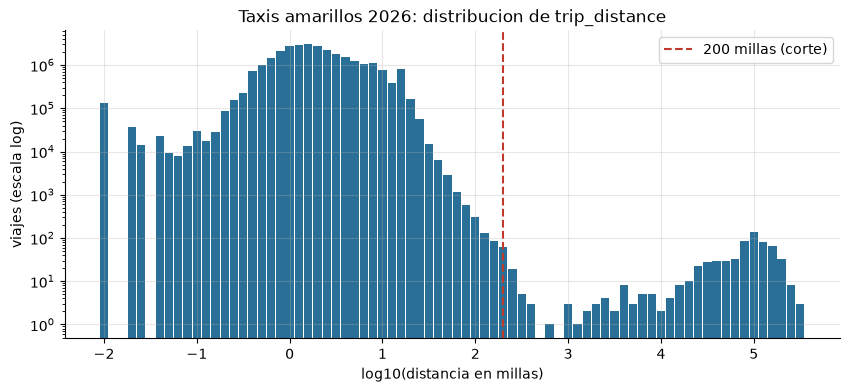

In [15]:
hist = con.sql("""
    SELECT floor(log10(trip_distance) * 10) / 10 AS log10_millas, count(*) AS viajes
    FROM read_parquet('/workspace/data/raw/yellow/*/*.parquet', union_by_name = true)
    WHERE trip_distance > 0
    GROUP BY 1 ORDER BY 1
""").df()
fig, ax = plt.subplots()
ax.bar(hist.log10_millas, hist.viajes, width=0.09, color="#2a6f97")
ax.set_yscale("log")
ax.set_xlabel("log10(distancia en millas)")
ax.set_ylabel("viajes (escala log)")
ax.set_title("Taxis amarillos 2026: distribucion de trip_distance")
ax.axvline(2.301, color="#c0392b", ls="--", label="200 millas (corte)")
ax.legend()
plt.show()

## Conclusiones de la exploracion

1. **Esquema heterogeneo:** amarillos y verdes nombran distinto las fechas (`tpep_*` vs `lpep_*`), cada tipo tiene columnas
   exclusivas (`Airport_fee` / `ehail_fee`, `trip_type`) y `request_source` solo existe desde 2026-06.
   **Decision:** leer siempre con `union_by_name = true` y construir una vista unificada (`trips`, en `sql/00_views.sql`).
2. **Registros sin datos de despacho:** ~26 % de los amarillos tienen nulos simultaneos en `passenger_count`, `RatecodeID`,
   `store_and_fwd_flag` y `congestion_surcharge` y `payment_type = 0` (Flex Fare / sin informar). **Decision:** conservarlos para
   conteos y montos, pero excluirlos de analisis de pasajeros y de tipo de pago.
3. **Valores imposibles:** fechas de 2001 y 2008, duraciones negativas, distancias de 328 mil millas, montos negativos (ajustes/
   reversos). **Decision:** vista `trips_clean` con reglas explicitas (mes del archivo, 1-240 min, 0-200 millas, montos positivos).
4. **Duplicados:** ~33 mil registros amarillos repetidos exactamente. Representan 0.11 % y no cambian los agregados de forma visible;
   se documentan pero no se eliminan para no alterar la fuente.